In [7]:
import yfinance as yf

# Download Apple stock prices for the last year
data = yf.download("GOLD", start="2024-01-01", end="2026-07-07")
print(data.head())

/tmp/ipykernel_790/3673423015.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("GOLD", start="2024-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open  Volume
Ticker           GOLD       GOLD       GOLD       GOLD    GOLD
Date                                                          
2024-01-02  27.615110  29.031992  27.516586  28.234409  315900
2024-01-03  26.761229  28.037359  26.735893  27.333610  316300
2024-01-04  27.464973  27.727705  26.714307  26.836291  262100
2024-01-05  27.352375  27.981057  27.059615  27.258541  174600
2024-01-08  27.511890  27.577573  26.507876  27.192857  203500


In [8]:
print(data.tail())

Price           Close       High        Low       Open  Volume
Ticker           GOLD       GOLD       GOLD       GOLD    GOLD
Date                                                          
2026-06-29  41.110001  41.790001  40.299999  41.759998  313600
2026-06-30  41.610001  41.939999  40.500000  40.950001  257200
2026-07-01  42.529999  43.400002  41.560001  41.560001  449600
2026-07-02  43.990002  45.290001  43.230000  43.330002  458700
2026-07-06  44.049999  45.000000  43.529999  44.320000  428400


In [9]:
ticker = yf.Ticker("GOLD")

# Company info
print(ticker.info)

# Historical prices
hist = ticker.history(period="1y")
print(hist.tail())


{'address1': '1550 Scenic Ave', 'address2': 'Suite 150', 'city': 'Costa Mesa', 'state': 'CA', 'zip': '92626', 'country': 'United States', 'phone': '844 455-4653', 'website': 'https://www.gold.com', 'industry': 'Capital Markets', 'industryKey': 'capital-markets', 'industryDisp': 'Capital Markets', 'sector': 'Financial Services', 'sectorKey': 'financial-services', 'sectorDisp': 'Financial Services', 'longBusinessSummary': 'Gold.com, Inc., together with its subsidiaries, operates as a precious metals company. It operates through three segments: Wholesale Sales & Ancillary Services, Direct-to-Consumer, and Secured Lending. The Wholesale Sales & Ancillary Services segment sells gold, silver, platinum, and palladium in the form of bars, plates, powders, wafers, grains, ingots, and coins. This segment also offers complementary services, such as receiving, handling, inventorying, processing, packing, and shipping of precious metals and custom coins on a secure basis; and designs and produces m

In [10]:
# Dividends
print(ticker.dividends)

# Stock splits
print(ticker.splits)


Date
2015-03-10 00:00:00-04:00    0.025
2015-05-12 00:00:00-04:00    0.025
2015-09-22 00:00:00-04:00    0.025
2015-11-10 00:00:00-05:00    0.025
2016-02-10 00:00:00-05:00    0.035
2016-05-11 00:00:00-04:00    0.035
2016-09-15 00:00:00-04:00    0.035
2016-11-09 00:00:00-05:00    0.035
2017-02-06 00:00:00-05:00    0.040
2017-05-11 00:00:00-04:00    0.040
2017-09-15 00:00:00-04:00    0.040
2017-11-22 00:00:00-05:00    0.040
2018-02-12 00:00:00-05:00    0.040
2020-09-18 00:00:00-04:00    0.750
2020-11-20 00:00:00-05:00    0.750
2021-09-17 00:00:00-04:00    1.000
2022-09-09 00:00:00-04:00    1.000
2022-10-06 00:00:00-04:00    0.200
2023-01-12 00:00:00-05:00    0.200
2023-04-14 00:00:00-04:00    0.200
2023-07-14 00:00:00-04:00    0.200
2023-09-11 00:00:00-04:00    1.000
2023-10-06 00:00:00-04:00    0.200
2024-01-12 00:00:00-05:00    0.200
2024-04-15 00:00:00-04:00    0.200
2024-07-18 00:00:00-04:00    0.200
2024-10-08 00:00:00-04:00    0.200
2025-01-14 00:00:00-05:00    0.200
2025-04-15 00:0

### Prepare Data for Model Training

To train a predictive model, we need to define our target variable and features. For stock price prediction, a common approach is to predict the next day's closing price based on historical prices.

First, let's ensure the `data` DataFrame is clean and contains only the necessary columns. We'll focus on the 'Close' price for this example. We will create lagged features (previous closing prices) and a target variable (the next day's closing price).

In [12]:
import numpy as np

# Create a new DataFrame with only the 'Close' price
df_model = data[['Close']].copy()

# Create lagged features (e.g., previous 1, 2, 3 days closing prices)
for i in range(1, 4):
    df_model[f'Close_Lag_{i}'] = df_model['Close'].shift(i)

# Create the target variable: next day's closing price
df_model['Target'] = df_model['Close'].shift(-1)

# Drop rows with NaN values that result from shifting
df_model.dropna(inplace=True)

# Display the prepared data
display(df_model.tail())

Price,Close,Close_Lag_1,Close_Lag_2,Close_Lag_3,Target
Ticker,GOLD,,,,
Date,,,,,
2026-06-26,41.919998,41.450001,41.320000,42.380001,41.110001
2026-06-29,41.110001,41.919998,41.450001,41.320000,41.610001
2026-06-30,41.610001,41.110001,41.919998,41.450001,42.529999
2026-07-01,42.529999,41.610001,41.110001,41.919998,43.990002
2026-07-02,43.990002,42.529999,41.610001,41.110001,44.049999


### Split Data into Training and Testing Sets

Before training a model, it's crucial to split the data into training and testing sets. The training set will be used to teach the model, and the testing set will be used to evaluate how well the model generalizes to new, unseen data.

We'll use a standard split, for example, 80% for training and 20% for testing. It's also important to separate the features (X) from the target variable (y).

In [13]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_model.drop('Target', axis=1)
y = df_model['Target']

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train.head())

X_train shape: (499, 4)
X_test shape: (125, 4)
y_train shape: (499,)
y_test shape: (125,)


Price,Close,Close_Lag_1,Close_Lag_2,Close_Lag_3
Ticker,GOLD,,,
Date,,,,
2025-08-06,21.919674,21.408083,20.611183,20.237328
2025-04-30,23.754507,23.491219,23.744753,24.339592
2024-01-16,27.022800,27.060606,25.888578,26.733076
2024-06-05,33.700844,33.468124,35.192104,36.037491
2024-06-20,32.361542,31.734642,30.974760,30.917770


### Model Training: Random Forest Regressor

For predicting continuous values like stock prices, regression models are essential. The Random Forest Regressor is a popular choice due to its ability to handle non-linear relationships, reduce overfitting compared to single decision trees, and provide good predictive accuracy. It works by constructing multiple decision trees during training and outputting the average prediction of the individual trees.

We will train the model using our `X_train` and `y_train` sets.

In [14]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
# n_estimators is the number of trees in the forest
# random_state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


### Model Prediction and Evaluation

After training, it's crucial to evaluate how well our model performs on unseen data. We'll use the `X_test` set to make predictions and then compare these predictions against the actual `y_test` values using common regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared. These metrics will give us an understanding of the model's accuracy and how much variance it explains.

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.9521
Mean Squared Error (MSE): 1.8192
Root Mean Squared Error (RMSE): 1.3488
R-squared (R2): 0.9772


### Visualize Predictions

Let's visualize the model's predictions against the actual values from the test set. This will give us a clearer picture of how well our model is tracking the stock price movements.

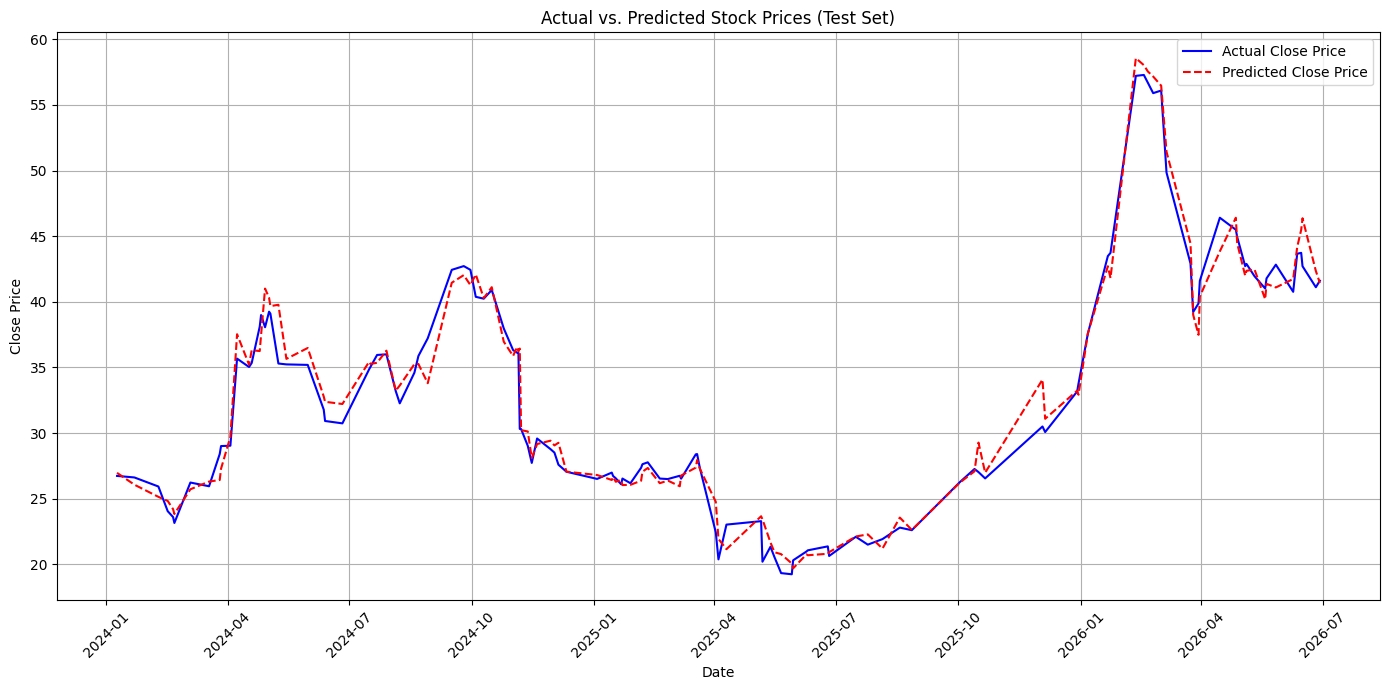

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for actual vs. predicted values for easier plotting
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df.index = y_test.index # Ensure index aligns for time series plotting

# Sort by index to ensure chronological order for plotting
results_df = results_df.sort_index()

plt.figure(figsize=(14, 7))
plt.plot(results_df.index, results_df['Actual'], label='Actual Close Price', color='blue')
plt.plot(results_df.index, results_df['Predicted'], label='Predicted Close Price', color='red', linestyle='--')
plt.title('Actual vs. Predicted Stock Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning with GridSearchCV

Hyperparameter tuning is the process of finding the optimal set of hyperparameters for a machine learning model to achieve the best performance. `GridSearchCV` exhaustively searches over specified parameter values for an estimator. It evaluates each combination using cross-validation and reports the best performing set of parameters.

We will define a `param_grid` with different values for key `RandomForestRegressor` hyperparameters such as:
- `n_estimators`: The number of trees in the forest.
- `max_features`: The number of features to consider when looking for the best split.
- `max_depth`: The maximum depth of the tree.
- `min_samples_split`: The minimum number of samples required to split an internal node.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node.

In [17]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required at each leaf node
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
# verbose=2 will show detailed progress
# n_jobs=-1 will use all available CPU cores
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("Starting GridSearchCV... This might take some time.")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

Starting GridSearchCV... This might take some time.
Fitting 3 folds for each of 216 candidates, totalling 648 fits
GridSearchCV completed.


### Best Parameters and Retraining the Model

After `GridSearchCV` finishes, we can retrieve the best combination of hyperparameters it found. We'll then use these optimal parameters to retrain our `RandomForestRegressor` and evaluate its performance again. This new model should theoretically perform better than the one trained with default parameters.

Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Performance of the Tuned Model:
Mean Absolute Error (MAE): 0.9349
Mean Squared Error (MSE): 1.6082
Root Mean Squared Error (RMSE): 1.2681
R-squared (R2): 0.9799


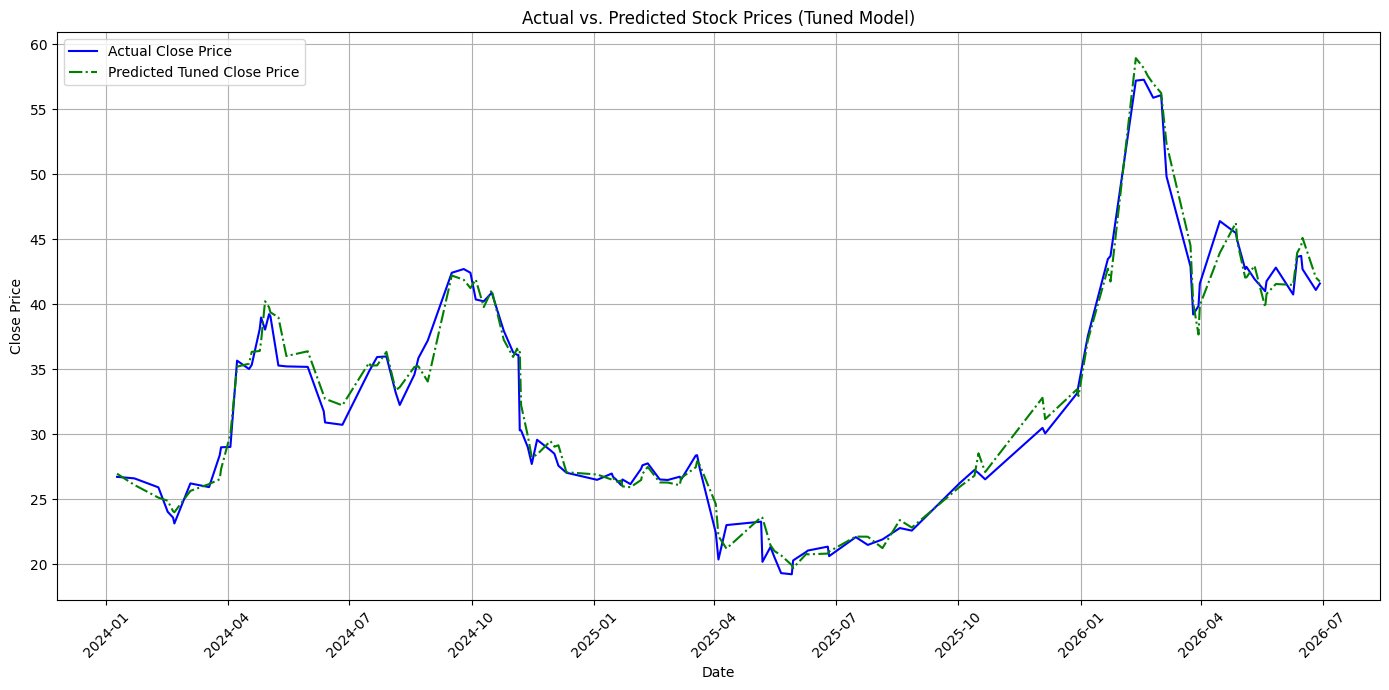

In [18]:
# Get the best parameters found by GridSearchCV
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

# Get the best estimator (model with best parameters)
best_model = grid_search.best_estimator_

# Make predictions with the best model on the test set
y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\nPerformance of the Tuned Model:")
print(f"Mean Absolute Error (MAE): {mae_tuned:.4f}")
print(f"Mean Squared Error (MSE): {mse_tuned:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.4f}")
print(f"R-squared (R2): {r2_tuned:.4f}")

# Visualize predictions from the tuned model
results_tuned_df = pd.DataFrame({'Actual': y_test, 'Predicted_Tuned': y_pred_tuned})
results_tuned_df.index = y_test.index
results_tuned_df = results_tuned_df.sort_index()

plt.figure(figsize=(14, 7))
plt.plot(results_tuned_df.index, results_tuned_df['Actual'], label='Actual Close Price', color='blue')
plt.plot(results_tuned_df.index, results_tuned_df['Predicted_Tuned'], label='Predicted Tuned Close Price', color='green', linestyle='-.')
plt.title('Actual vs. Predicted Stock Prices (Tuned Model)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()